## install librarry

In [5]:
%pip install -q "transformers>=4.45.0" "peft>=0.11.0" "accelerate" "qwen-vl-utils" "datasets" "tqdm"


Note: you may need to restart the kernel to use updated packages.


## Import + cấu hình chung
> Qwen2-VL-2B-Instruct

In [6]:
import os
import json
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Any

import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import AdamW
from tqdm.auto import tqdm
from PIL import Image

from transformers import (
    Qwen2VLForConditionalGeneration,
    AutoProcessor,
    get_cosine_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

JSONL_PATH = Path("/kaggle/input/datasetrm2/rm_pairs_llava_13k.jsonl")
COCO_ROOT = Path("/kaggle/input/datasetrm2/")
MODEL_ID = "Qwen/Qwen2-VL-2B-Instruct"
OUTPUT_DIR = Path("/kaggle/working/qwen2vl_sft_stage0")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
if torch.cuda.is_available() and torch.cuda.is_bf16_supported():
    torch_dtype = torch.bfloat16
else:
    torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

print("Device:", device)
print("Torch dtype:", torch_dtype)
print("JSONL exists:", JSONL_PATH.exists())
print("COCO_ROOT exists:", COCO_ROOT.exists())

Device: cuda
Torch dtype: torch.bfloat16
JSONL exists: True
COCO_ROOT exists: True


## Load JSONL & dataframe  

In [7]:
import pandas as pd

assert JSONL_PATH.exists(), f"Không tìm thấy file: {JSONL_PATH}"

records = []
with open(JSONL_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        obj = json.loads(line)
        # Expect keys: image_path, caption_chosen (GPT-4V), caption_rejected (COCO), ...
        records.append(
            {
                "image_path": obj["image_path"],
                "caption_gold": obj["caption_chosen"],
                "caption_short": obj.get("caption_rejected", ""),
            }
        )

df = pd.DataFrame(records)
print("Tổng số mẫu:", len(df))
df.head()

Tổng số mẫu: 13000


,image_path,caption_gold,caption_short
0,coco_train2017_subset/000000000009.jpg,"In the center of the image, a vibrant blue lun...",A bunch of trays that have different food.
1,coco_train2017_subset/000000000025.jpg,This image captures a serene moment in a zoo e...,A giraffe mother with its baby in the forest.
2,coco_train2017_subset/000000000030.jpg,"The image presents a serene garden scene, cent...",A white vase filled with different colored flo...
3,coco_train2017_subset/000000000034.jpg,This is a detailed description of the image: -...,a Zebra grazing on grass in a green open field.
4,coco_train2017_subset/000000000036.jpg,"In the image, a young woman is the main subjec...",A woman in a floral swimsuit holds a pink umbr...


##  Dataset & hàm build đường dẫn ảnh
1. text input cho training SFT
2. prompt + ground-truth caption (GPT-4V)

In [8]:
PROMPT = "Describe the image in a detailed, accurate English caption."

def resolve_image_path(image_path_str: str) -> Path:
    p = COCO_ROOT / image_path_str
    if p.exists():
        return p
    alt = COCO_ROOT / "coco_train2017_subset" / "data13k" / os.path.basename(image_path_str)
    if alt.exists():
        return alt
    raise FileNotFoundError(f"Không tìm thấy ảnh cho: {image_path_str}")

class CocoCaptionSFTDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        row = self.df.iloc[idx]
        img_path = resolve_image_path(row["image_path"])
        image = Image.open(img_path).convert("RGB")

        caption_gold = row["caption_gold"]
        caption_short = row["caption_short"]

        full_text = f"{PROMPT}\n\n{caption_gold}"

        sample = {
            "image": image,
            "text": full_text,
            "caption_gold": caption_gold,
            "caption_short": caption_short,
            "image_path": str(img_path),
        }
        return sample

# Tạo dataset full
full_dataset = CocoCaptionSFTDataset(df)
print("Dataset length:", len(full_dataset))

# Test 1 sample
test_sample = full_dataset[0]
test_sample["image"], test_sample["text"][:500]


Dataset length: 13000


(<PIL.Image.Image image mode=RGB size=640x480>,
 'Describe the image in a detailed, accurate English caption.\n\nIn the center of the image, a vibrant blue lunch tray holds four containers, each brimming with a variety of food items. The containers, two in pink and two in yellow, are arranged in a 2x2 grid. In the top left pink container, a slice of bread rests, lightly spread with butter and sprinkled with a handful of almonds. The bread is cut into a rectangle, and the almonds are scattered across its buttery surface. Adjacent to it in the top ')

## train/test/val 80/10/10

In [9]:
total_len = len(full_dataset)
val_ratio = 0.1
test_ratio = 0.1
val_len = int(total_len * val_ratio)
test_len = int(total_len * test_ratio)
train_len = total_len - val_len - test_len

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_len, val_len, test_len],
    generator=torch.Generator().manual_seed(42),
)

print(f"train: {len(train_dataset)}, val: {len(val_dataset)}, test: {len(test_dataset)}")


train: 10400, val: 1300, test: 1300


## Giảm kích thước train_dataset (quá nặng T.T)
giảm 4/5 => vẫn đủ cho việc training

In [10]:
import torch

FULL_TRAIN_LEN = len(train_dataset)
print("Full train length:", FULL_TRAIN_LEN)

N_TRAIN_SFT = 2000

if FULL_TRAIN_LEN > N_TRAIN_SFT:
    indices = torch.randperm(FULL_TRAIN_LEN)[:N_TRAIN_SFT]
    train_subset = [train_dataset[i] for i in indices.tolist()]
else:
    train_subset = list(train_dataset)
    N_TRAIN_SFT = FULL_TRAIN_LEN

print("train_subset length:", len(train_subset))

Full train length: 10400
Using train_subset length: 2000


## Load Qwen2-VL processor & model + LoRA config

In [15]:
from qwen_vl_utils import process_vision_info

processor = AutoProcessor.from_pretrained(
    MODEL_ID,
)

model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    torch_dtype=torch_dtype,
    device_map=None,
)
model.gradient_checkpointing_enable()
model.enable_input_require_grads()

model = model.to(device)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

trainable params: 18,464,768 || all params: 2,227,450,368 || trainable%: 0.8290


## Data collator cho Qwen2-VL (SFT)
1) Tạo messages dạng chat có image + text
2) Dùng processor để tạo input_ids, pixel_values, attention_mask
3) labels = input_ids (huấn luyện tái tạo toàn bộ sequence)

In [18]:
@dataclass
class Qwen2VLCollator:
    processor: Any

    def __call__(self, batch: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        messages_batch = []
        for sample in batch:
            image = sample["image"]
            text = sample["text"]
            messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image", "image": image},
                        {"type": "text", "text": PROMPT},
                    ],
                },
                {
                    "role": "assistant",
                    "content": [
                        {"type": "text", "text": sample["caption_gold"]},
                    ],
                },
            ]
            messages_batch.append(messages)
        inputs = processor.apply_chat_template(
            messages_batch,
            tokenize=True,
            add_generation_prompt=False,   
            return_tensors="pt",
            return_dict=True,
            padding=True,
        )
        input_ids = inputs["input_ids"]
        labels = input_ids.clone()

        inputs["labels"] = labels
        return inputs

collator = Qwen2VLCollator(processor=processor)

## dataloader cho train/val

In [19]:
BATCH_SIZE = 2  # bắt đầu nhỏ cho an toàn VRAM

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collator,
    num_workers=2,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collator,
)

len(train_loader), len(val_loader)

(1000, 650)

## train 1 epoch & evaluate

In [20]:
def train_one_epoch(model, dataloader, optimizer, scheduler=None, max_grad_norm=1.0):
    model.train()
    total_loss = 0.0
    n_steps = 0

    for batch in tqdm(dataloader, desc="Train epoch", leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        n_steps += 1

    return total_loss / max(1, n_steps)


@torch.no_grad()
def evaluate(model, dataloader):
    model.eval()
    total_loss = 0.0
    n_steps = 0

    for batch in tqdm(dataloader, desc="Eval", leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss

        total_loss += loss.item()
        n_steps += 1

    return total_loss / max(1, n_steps)

##  optimizer, scheduler & vòng lặp SFT warm-up (giới hạn số bước)

In [21]:
EPOCHS = 1        
LR = 5e-5
WARMUP_RATIO = 0.03

MAX_TRAIN_STEPS = 2000  

optimizer = AdamW(model.parameters(), lr=LR)

num_update_steps_per_epoch = len(train_loader)
max_train_steps = min(EPOCHS * num_update_steps_per_epoch, MAX_TRAIN_STEPS)
num_warmup_steps = int(WARMUP_RATIO * max_train_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=max_train_steps,
)

best_val_loss = float("inf")
best_ckpt_path = OUTPUT_DIR / "qwen2vl_sft_stage0_best.pt"

global_step = 0
stop_training = False

for epoch in range(EPOCHS):
    if stop_training:
        break

    print(f"===== Epoch {epoch+1}/{EPOCHS} =====")
    model.train()
    total_train_loss = 0.0
    n_steps = 0

    for batch in tqdm(train_loader, desc="Train epoch", leave=False):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        total_train_loss += loss.item()
        n_steps += 1
        global_step += 1

        if global_step >= max_train_steps:
            print(f"Reached max_train_steps = {max_train_steps}, stop training.")
            stop_training = True
            break

    train_loss = total_train_loss / max(1, n_steps)
    val_loss = evaluate(model, val_loader)

    print(f"Train loss: {train_loss:.4f} | Val loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(">>> New best val loss, saving checkpoint:", best_ckpt_path)
        torch.save(model.state_dict(), best_ckpt_path)

print("Best val loss:", best_val_loss)

===== Epoch 1/1 =====


Train epoch:   0%|          | 0/1000 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...
`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


Reached max_train_steps = 1000, stop training.


Eval:   0%|          | 0/650 [00:00<?, ?it/s]

Train loss: 4.9498 | Val loss: 4.7243
>>> New best val loss, saving checkpoint: /kaggle/working/qwen2vl_sft_stage0/qwen2vl_sft_stage0_best.pt
Best val loss: 4.724305119881263


In [22]:
# Load lại best checkpoint

best_ckpt_path = OUTPUT_DIR / "qwen2vl_sft_stage0_best.pt"
print("Best ckpt path:", best_ckpt_path, "| exists:", best_ckpt_path.exists())

if best_ckpt_path.exists():
    state = torch.load(best_ckpt_path, map_location="cpu")
    model.load_state_dict(state)
    model = model.to(device)
    print("Loaded best SFT checkpoint.")
else:
    print("Chưa có checkpoint tốt nhất, dùng model hiện tại.")

Best ckpt path: /kaggle/working/qwen2vl_sft_stage0/qwen2vl_sft_stage0_best.pt | exists: True
Loaded best SFT checkpoint.


## demo

Image: /kaggle/input/datasetrm2/coco_train2017_subset/data13k/000000041027.jpg


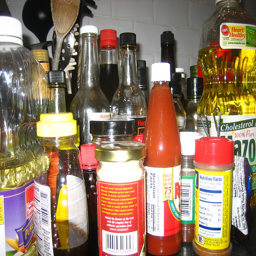


[GEN]: This image captures a vibrant scene of a kitchen counter, teeming with an array of condiments and spices. The counter, a canvas of colors, is adorned with a variety of bottles and jars, each with its own unique shape and size. The bottles, predominantly clear, are scattered across the counter, their contents hidden from view. Among them, a few jars and bottles stand out with their vibrant

[GOLD]: This image captures a scene of culinary chaos on a kitchen countertop. There are **12** objects in total, a mix of bottles and jars, scattered haphazardly across the black surface. Some of these containers overlap with each other, while others stand alone, creating a sense of disarray. The objects vary in color, with hues ranging from vibrant red to sunny yellow and stark black. Some of the contai ...
Image: /kaggle/input/datasetrm2/coco_train2017_subset/data13k/000000035961.jpg


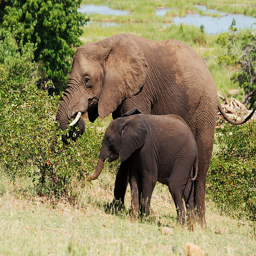


[GEN]: This image captures a serene moment in the wild. It features two elephants, an adult and a juvenile, in a grassy field. The adult elephant, with its large ears and long trunk, is on the left side of the image. It appears to be feeding on the lush green grass, its trunk extended towards the ground. The juvenile elephant, with its smaller size and darker color, is on

[GOLD]: In the serene expanse of a grassy field, a mother elephant and her calf are captured in a moment of tranquility. The mother, a majestic creature with a coat of gray, stands on the left side of the image. Her trunk, a symbol of strength and dexterity, is extended towards the ground, perhaps exploring the terrain or searching for food. Her tusks, a testament to her age and maturity, are clearly visi ...
Image: /kaggle/input/datasetrm2/coco_train2017_subset/data13k/000000026913.jpg


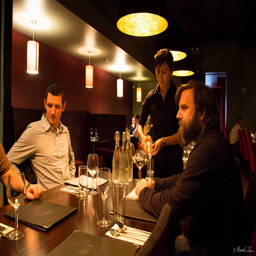


[GEN]: This image captures a moment in a dimly lit restaurant, where three men are seated at a table. The man on the left is dressed in a white shirt, while the man in the middle is wearing a black shirt. The man on the right is dressed in a black jacket. The table they are seated at is set with a black menu and a black napkin, adding to the sophisticated ambiance

[GOLD]: In the heart of a dimly lit restaurant, a group of people are gathered around a table, engrossed in conversation. The table, draped in a pristine white tablecloth, is adorned with several wine glasses and bottles, suggesting a relaxed and leisurely dining experience. A waiter, dressed in a crisp white shirt and black pants, is in the midst of pouring wine into one of the glasses, adding to the con ...


In [23]:
from qwen_vl_utils import process_vision_info

@torch.no_grad()
def generate_caption_for_sample(sample, max_new_tokens=80):
    model.eval()

    image = sample["image"]
    caption_gold = sample["caption_gold"]

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": PROMPT},
            ],
        }
    ]

    inputs = processor.apply_chat_template(
        [messages],
        tokenize=True,
        add_generation_prompt=True, 
        return_tensors="pt",
        return_dict=True,
        padding=True,
    ).to(device)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        top_p=0.9,
        temperature=0.7,
    )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs["input_ids"], generated_ids)
    ]
    outputs = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )

    return outputs[0], caption_gold

for i in range(3):
    sample = val_dataset[i]
    gen_caption, gold_caption = generate_caption_for_sample(sample)
    print("=" * 80)
    print("Image:", sample["image_path"])
    display(sample["image"].resize((256, 256)))
    print("\n[GEN]:", gen_caption)
    print("\n[GOLD]:", gold_caption[:400], "...")

In [24]:
# =======================
# Cell 13: Thống kê length (L_short, L_gold, ratio)
# =======================

import numpy as np

length_records = []

for _, row in df.iterrows():
    short = str(row["caption_short"])
    gold = str(row["caption_gold"])

    # bỏ những sample short rỗng/thiếu
    if not short.strip() or not gold.strip():
        continue

    L_short = len(short.split())
    L_gold = len(gold.split())
    if L_short == 0:
        continue

    ratio = L_gold / L_short
    length_records.append((L_short, L_gold, ratio))

length_records = np.array(length_records)
L_short_arr = length_records[:, 0]
L_gold_arr = length_records[:, 1]
ratio_arr = length_records[:, 2]

print("Num valid samples:", len(ratio_arr))

def describe(arr, name):
    print(f"--- {name} ---")
    print("  mean    :", float(np.mean(arr)))
    print("  median  :", float(np.median(arr)))
    print("  p25     :", float(np.quantile(arr, 0.25)))
    print("  p75     :", float(np.quantile(arr, 0.75)))
    print("  p90     :", float(np.quantile(arr, 0.90)))
    print("  min/max :", float(np.min(arr)), "/", float(np.max(arr)))
    print()

describe(L_short_arr, "L_short (COCO)")
describe(L_gold_arr,  "L_gold (GPT-4V)")
describe(ratio_arr,   "ratio = L_gold / L_short")


Num valid samples: 13000
--- L_short (COCO) ---
  mean    : 10.465076923076923
  median  : 10.0
  p25     : 9.0
  p75     : 11.0
  p90     : 13.0
  min/max : 7.0 / 43.0

--- L_gold (GPT-4V) ---
  mean    : 168.098
  median  : 168.0
  p25     : 150.0
  p75     : 186.0
  p90     : 205.0
  min/max : 70.0 / 435.0

--- ratio = L_gold / L_short ---
  mean    : 16.707278494143875
  median  : 16.454545454545453
  p25     : 13.666666666666666
  p75     : 19.5
  p90     : 22.25
  min/max : 4.27906976744186 / 51.375



In [27]:
# =======================
# Cell 14 (mới): Đặt NGƯỠNG length bonus THỦ CÔNG & xem lại stats
# =======================

import numpy as np
import json

# Giả sử length_records, L_short_arr, L_gold_arr, ratio_arr đã được tính ở Cell 13

print("Num valid samples:", len(ratio_arr))

def describe(arr, name):
    print(f"--- {name} ---")
    print("  mean    :", float(np.mean(arr)))
    print("  median  :", float(np.median(arr)))
    print("  p25     :", float(np.quantile(arr, 0.25)))
    print("  p75     :", float(np.quantile(arr, 0.75)))
    print("  p90     :", float(np.quantile(arr, 0.90)))
    print("  min/max :", float(np.min(arr)), "/", float(np.max(arr)))
    print()

describe(L_short_arr, "L_short (COCO)")
describe(L_gold_arr,  "L_gold (GPT-4V)")
describe(ratio_arr,   "ratio = L_gold / L_short")

# -------------------------------
# THỦ CÔNG chọn vài bộ ngưỡng ratio
# -------------------------------
# Ý tưởng: caption lý tưởng ~1.7–2.0 lần COCO, không cần dài như GPT-4V
# Ta thử 3 cấu hình khác nhau để so sánh:

candidate_length_cfgs = {
    "cfg_A_soft": {   # mềm, rộng
        "min_ratio": 1.3,
        "target_ratio": 2.0,
        "max_ratio": 3.0,
    },
    "cfg_B_tight": {  # tập trung quanh 1.7–2.0
        "min_ratio": 1.4,
        "target_ratio": 1.9,
        "max_ratio": 2.5,
    },
    "cfg_C_longer": { # cho phép dài hơn một chút
        "min_ratio": 1.5,
        "target_ratio": 2.2,
        "max_ratio": 3.5,
    },
}

print("Candidate length bonus configs:")
for name, cfg in candidate_length_cfgs.items():
    print(f"{name}: min={cfg['min_ratio']:.2f}, target={cfg['target_ratio']:.2f}, max={cfg['max_ratio']:.2f}")

# Chọn tạm 1 cấu hình default (sau khi xem output Cell 15 có thể đổi)
default_cfg_name = "cfg_B_tight"
length_cfg = candidate_length_cfgs[default_cfg_name]

print("\nDefault length config (tạm):", default_cfg_name, "->", length_cfg)

# Lưu default config để dùng ở notebook RL sau
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
with open(OUTPUT_DIR / "length_bonus_config.json", "w", encoding="utf-8") as f:
    json.dump({"default_name": default_cfg_name, **length_cfg}, f, indent=2)

print("Saved default length_bonus_config.json at:", OUTPUT_DIR / "length_bonus_config.json")


Num valid samples: 13000
--- L_short (COCO) ---
  mean    : 10.465076923076923
  median  : 10.0
  p25     : 9.0
  p75     : 11.0
  p90     : 13.0
  min/max : 7.0 / 43.0

--- L_gold (GPT-4V) ---
  mean    : 168.098
  median  : 168.0
  p25     : 150.0
  p75     : 186.0
  p90     : 205.0
  min/max : 70.0 / 435.0

--- ratio = L_gold / L_short ---
  mean    : 16.707278494143875
  median  : 16.454545454545453
  p25     : 13.666666666666666
  p75     : 19.5
  p90     : 22.25
  min/max : 4.27906976744186 / 51.375

Candidate length bonus configs:
cfg_A_soft: min=1.30, target=2.00, max=3.00
cfg_B_tight: min=1.40, target=1.90, max=2.50
cfg_C_longer: min=1.50, target=2.20, max=3.50

Default length config (tạm): cfg_B_tight -> {'min_ratio': 1.4, 'target_ratio': 1.9, 'max_ratio': 2.5}
Saved default length_bonus_config.json at: /kaggle/working/qwen2vl_sft_stage0/length_bonus_config.json


In [28]:
# =======================
# Cell 15 (mới): Hàm length_bonus + thử nhiều cấu hình trên vài ratio
# =======================

def compute_length_bonus(
    ratio: float,
    min_ratio: float,
    target_ratio: float,
    max_ratio: float,
    min_penalty: float = -0.2,
    max_bonus: float = 1.0,
) -> float:
    """
    Hàm piecewise đơn giản:
    - ratio <= 1.0: phạt nhẹ (min_penalty) vì quá ngắn
    - 1.0 < ratio < min_ratio: từ 0 -> ~0.5 * max_bonus
    - min_ratio <= ratio <= target_ratio: lên dần đến max_bonus
    - target_ratio < ratio <= max_ratio: giảm nhẹ từ max_bonus -> ~0.7 * max_bonus
    - ratio > max_ratio: giảm dần về ~0.3 * max_bonus (caption quá dài)
    """
    if ratio <= 1.0:
        return float(min_penalty)

    # (1.0, min_ratio): 0 -> 0.5 * max_bonus
    if ratio < min_ratio:
        t = (ratio - 1.0) / (min_ratio - 1.0 + 1e-8)
        return 0.5 * max_bonus * float(t)

    # [min_ratio, target_ratio]: 0.5 * max_bonus -> max_bonus
    if ratio <= target_ratio:
        t = (ratio - min_ratio) / (target_ratio - min_ratio + 1e-8)
        return 0.5 * max_bonus + 0.5 * max_bonus * float(t)

    # (target_ratio, max_ratio]: max_bonus -> 0.7 * max_bonus
    if ratio <= max_ratio:
        t = (ratio - target_ratio) / (max_ratio - target_ratio + 1e-8)
        return max_bonus - 0.3 * max_bonus * float(t)

    # ratio quá lớn: giảm dần về 0.3 * max_bonus (cap ở đây luôn)
    extra = min(ratio - max_ratio, 1.0)  # cap thêm 1.0
    return max_bonus * (0.7 - 0.4 * extra)  # từ 0.7 xuống 0.3


# -------------------------------
# Thử các cấu hình trên một loạt ratio
# -------------------------------

test_ratios = [0.8, 1.0, 1.2, 1.5, 1.8, 2.0, 2.5, 3.0, 3.5, 4.0]

for cfg_name, cfg in candidate_length_cfgs.items():
    print("\n============================================")
    print(f"Config: {cfg_name} | min={cfg['min_ratio']:.2f}, target={cfg['target_ratio']:.2f}, max={cfg['max_ratio']:.2f}")
    print("ratio\tbonus")
    for r in test_ratios:
        b = compute_length_bonus(
            r,
            min_ratio=cfg["min_ratio"],
            target_ratio=cfg["target_ratio"],
            max_ratio=cfg["max_ratio"],
            min_penalty=-0.2,
            max_bonus=1.0,
        )
        print(f"{r:.2f}\t{b:.3f}")



Config: cfg_A_soft | min=1.30, target=2.00, max=3.00
ratio	bonus
0.80	-0.200
1.00	-0.200
1.20	0.333
1.50	0.643
1.80	0.857
2.00	1.000
2.50	0.850
3.00	0.700
3.50	0.500
4.00	0.300

Config: cfg_B_tight | min=1.40, target=1.90, max=2.50
ratio	bonus
0.80	-0.200
1.00	-0.200
1.20	0.250
1.50	0.600
1.80	0.900
2.00	0.950
2.50	0.700
3.00	0.500
3.50	0.300
4.00	0.300

Config: cfg_C_longer | min=1.50, target=2.20, max=3.50
ratio	bonus
0.80	-0.200
1.00	-0.200
1.20	0.200
1.50	0.500
1.80	0.714
2.00	0.857
2.50	0.931
3.00	0.815
3.50	0.700
4.00	0.500
